In [44]:
import os
import pandas as pd
import datetime
import random
import time

from openai import OpenAI, RateLimitError
from any_llm import completion, responses, list_models
from tqdm import tqdm
from importlib import reload

import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult
import Models_Utils
import Data
from VotingResult import VotingResult

In [2]:
LANGUAGE = SoD_Utils.LANGUAGE_CZ

# provider = "ollama"
# model = "jean-luc/tiger-gemma-9b-v3:fp16"

provider = "openai"
model = "gpt-4.1-nano"   # GPT-4.1 Nano (cheapest, fastest)
#model = "gpt-4o-mini"     # GPT-4o Mini (cheaper, faster)
#model = "gpt-4.1"       # GPT-4.1 (flagship reasoning model)
#model = "gpt-4o"        # GPT-4 Omni (fast, high quality)

temperature = 0

responses_api = Models_Utils.check_response_api_support(provider)

In [3]:
data_path = path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3880 entries, 0 to 3879
Columns: 170 entries, id to lca_DK_n_8
dtypes: category(163), float64(7)
memory usage: 864.0 KB


In [4]:
def process_SoD_response(row):
    # --- 1. Basic Information ---
    # Renames Czech keys to English and performs initial data cleaning.
    processed_data = {
        'gender': row.get('GENDER').lower(),
        'age': int(row.get('AGE1', 0)),
        'education_level': row.get('EDU', '').lower(),
        'region': row.get('KRAJ'),
        'district': row.get('OKRES'),
        'town_size': SoD_Utils.process_town_size(row),
        'employment_status': SoD_Utils.process_employment(row),
        'income_range': SoD_Utils.process_income(row),
        'living_standard': row.get('Q19','').lower(),
        'interest_in_politics': row.get('Q20','').lower(),
        'voted_party': row.get('Q21'),
    }

    # --- 2. Additional Survey Questions ---
    # Merges the dictionary of additional questions into the main one.
    additional_data = {
        # 'opinion_on_eu': row.get('Q18','').lower(),
        # 'opinion_on_nato': row.get('Q17','').lower(),
        # 'covid_vaccinated': row.get('Q23','').lower(),
    }
    processed_data.update(additional_data)

    return processed_data

In [5]:
data = [process_SoD_response(df.loc[i]) for i in df.index]
data = pd.DataFrame(data, index=df.index)
data

,gender,age,education_level,region,district,town_size,employment_status,income_range,living_standard,interest_in_politics,voted_party
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,spíše dobrou,velmi se zajímám,Koalice PIRÁTI a STAROSTOVÉ
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,"ani dobrou, ani špatnou",spíše se zajímám,ANO 2011
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Nechci uvést
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,velmi dobrou,vůbec se nezajímám,Jiná strana
...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,spíše se nezajímám,ANO 2011
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,None,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,vůbec se nezajímám,Nechci uvést
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše špatnou,nevím,Nechci uvést


In [6]:
instructions = """
Jsi expertní AI asistent specializovaný na analýzu českého politického chování. Tvým úkolem je na základě demografického a postojového profilu respondenta odhadnout jeho volební chování ve volbách do Poslanecké sněmovny Parlamentu ČR v roce 2021.

Tvůj výstup MUSÍ být JSON objekt, který přesně odpovídá Pydantic modelu `VotingResult`. Jiný formát není přípustný.

Dodržuj tato pravidla:
1.  Analyzuj VŠECHNY poskytnuté informace o respondentovi (věk, vzdělání, bydliště, příjem, postoje k EU/NATO atd.).
2.  Na základě analýzy odhadni dvě klíčové věci:
    a) Jaká je pravděpodobnost, že respondent vůbec šel k volbám.
    b) Pokud volil, jaké jsou pravděpodobnosti pro jednotlivé politické strany.
3.  Vygeneruj JSON, který bude validní oproti poskytnutým Pydantic modelům.
4.  Dbej na to, aby součet pravděpodobností v objektu `voted_or_not` byl přesně 1.0.
5.  Dbej na to, aby součet pravděpodobností VŠECH stran v seznamu `parties` byl přesně 1.0."""


prompt_question = " Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:"

### Creating Prompt

In [7]:
respondent = data.iloc[143]
prompt = SoD_Utils.create_respondent_description(respondent) + prompt_question
prompt

'Jsem muž, je mi 43 let, mé vzdělání je základní + středoškolské vzdělání bez maturity. Žiji v Středočeském kraji, v okresu Beroun a obci o velikosti Méně než 1.000 obyvatel. Z hlediska zaměstnání jsem zaměstnanec na plný úvazek a příjem naší domácnosti je 40.001 - 60.000 Kč. Nemám ani dobrou, ani špatnou životní úroveň. Spíše se nezajímám o politiku. Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:'

In [17]:
# Pure GPT call
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.parse(
    model=model,
    temperature=temperature,
    #instructions=INSTRUCTIONS,
    input=prompt,
    text_format=VotingResult.VotingResult
)

voted = response.output_parsed
response.output_parsed

VotingResult(voted_or_not=VotedProbability(voted=0.8, not_voted=0.2), parties=[PartyProbability(name='ANO 2011', probability=0.25), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.15), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.1), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.1), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.2), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.05), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.05), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.05), PartyProbability(name='Jiná strana', probability=0.0)])

In [19]:
# respons any llm - Structure does not work
response = responses(
    provider=provider,
    model=model,
    temperature=temperature,
    #instructions=INSTRUCTIONS,
    input_data=prompt,
    text=VotingResult.VotingResult
)

TypeError: Object of type ModelMetaclass is not JSON serializable

In [14]:
response = completion(
    provider=provider,
    model=model,
    temperature=temperature,
    messages=[
        # {"role": "system", "content": INSTRUCTIONS},
        {"role": "user", "content": prompt }
    ],
    response_format=VotingResult.VotingResult
)
voted = VotingResult.VotingResult.model_validate_json(response.choices[0].message.content)
response.choices[0].message

ChatCompletionMessage(content='{"voted_or_not":{"voted":1.0,"not_voted":0.0},"parties":[{"name":"ANO 2011","probability":0.0},{"name":"Koalice Spolu (ODS, TOP 09, KDU-ČSL)","probability":0.0},{"name":"Koalice PIRÁTI a STAROSTOVÉ","probability":0.0},{"name":"Komunistická strana Čech a Moravy (KSČM)","probability":0.0},{"name":"Svoboda a přímá demokracie – Tomio Okamura (SPD)","probability":0.0},{"name":"Česká strana sociálně demokratická (ČSSD)","probability":0.0},{"name":"Trikolóra, Svobodní a Soukromníci","probability":0.0},{"name":"Přísaha Roberta Šlachty","probability":0.0},{"name":"Jiná strana","probability":0.0}]}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None, reasoning=None, parsed={'voted_or_not': {'voted': 1.0, 'not_voted': 0.0}, 'parties': [{'name': 'ANO 2011', 'probability': 0.0}, {'name': 'Koalice Spolu (ODS, TOP 09, KDU-ČSL)', 'probability': 0.0}, {'name': 'Koalice PIRÁTI a STAROSTOVÉ', 'probability': 0.0}, {'name': 'Komun

In [18]:
p = 0
print(voted.voted_or_not)
for party_vote in voted.parties:
    print(f"{party_vote.name}: {party_vote.probability}")
    p += party_vote.probability
print(f"p_sum = {p}")

voted=0.8 not_voted=0.2
ANO 2011: 0.25
Koalice Spolu (ODS, TOP 09, KDU-ČSL): 0.15
Koalice PIRÁTI a STAROSTOVÉ: 0.1
Komunistická strana Čech a Moravy (KSČM): 0.1
Svoboda a přímá demokracie – Tomio Okamura (SPD): 0.2
Česká strana sociálně demokratická (ČSSD): 0.05
Trikolóra, Svobodní a Soukromníci: 0.05
Přísaha Roberta Šlachty: 0.05
Jiná strana: 0.0
p_sum = 0.9500000000000002


### RUN experiment


In [8]:
respondents = data#.sample(n=200, random_state=42)

In [47]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

voting_results = {}
skipped_respondents = []

# from copy import copy
#
# respondents = data.iloc[skipped_respondents]
# skipped_respondents_backup = copy(skipped_respondents)
# skipped_respondents = []

In [57]:
import concurrent.futures

def process_respondent(i, respondent, retries=3):
    for attempt in range(retries):
        try:
            prompt = SoD_Utils.create_respondent_description(respondent) + prompt_question
            response = client.responses.parse(
                model=model,
                temperature=temperature,
                input=prompt,
                text_format=VotingResult.VotingResult
            )
            return i, response.output_parsed
        except RateLimitError:
            wait = (2 ** attempt) + random.random()
            print(f"Rate limit hit. Retrying in {wait:.1f}s...")
            time.sleep(wait)
        except Exception as e:
            print(f"Error processing respondent {i}: {e}")
            return i, None
    return i, None


with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(process_respondent, i, respondents.loc[i]): i for i in respondents.index}
    for future in tqdm(concurrent.futures.as_completed(futures), total=len(respondents)):
        i, voted = future.result() # Get the result from the completed future
        if voted:
            voting_results[i] = voted
        else:
            skipped_respondents.append(i)

# The voting_results dictionary is now populated with the results.

100%|██████████| 15/15 [00:07<00:00,  2.05it/s]


In [60]:
print(len(respondents), len(voting_results), len(skipped_respondents))
print(skipped_respondents)

3880 3880 0


### Save Results

In [15]:
Save_Utils.save_results_to_json(voting_results, f"results/voting_results_n={len(respondents)}_t={temperature}_{model}.json")
Save_Utils.save_results_to_json(voting_results, f"results/voting_results_n={len(respondents)}_t={temperature}_{model}_{datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")}.json")

Successfully saved 3880 results (with IDs) to results/voting_results_n=3880_t=0_gpt-4.1.json
Successfully saved 3880 results (with IDs) to results/voting_results_n=3880_t=0_gpt-4.1_2025-09-05-09-41-22.json


In [41]:
voting_results = Save_Utils.load_results_from_json(f"results/voting_results_n={len(respondents)}_t={temperature}_{model}.json", VotingResult.VotingResult)

# voting_results = Save_Utils.load_results_from_json(f"results/voting_results_n=3880_t=0_gpt-4.1-nano.json", VotingResult.VotingResult)
# voting_results = Save_Utils.load_results_from_json(f"results/voting_results_n=3880_t=0_gpt-4o-mini.json", VotingResult.VotingResult)
# voting_results = Save_Utils.load_results_from_json(f"results/voting_results_n=3880_t=0_gpt-4.1.json", VotingResult.VotingResult)

Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o-mini.json


### Visualization

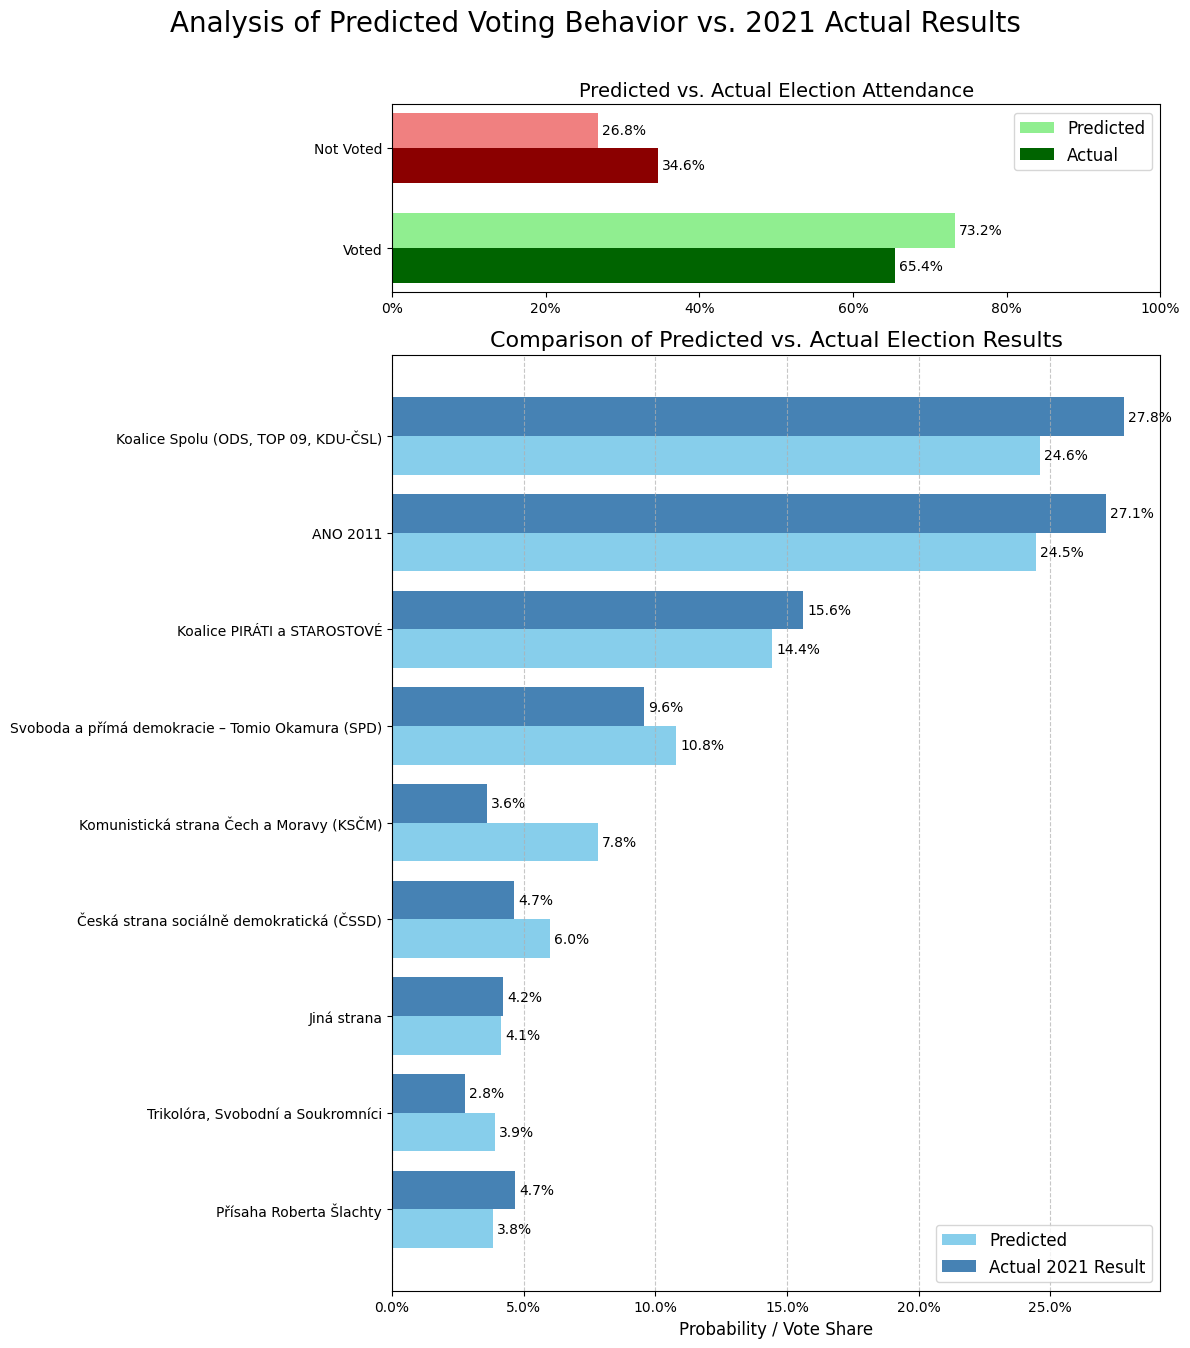

In [46]:
predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(voting_results.values(), True, True)
#actual_parties, actual_attendance = SoD_Utils.get_actual_results(respondents, True)
actual_parties, actual_attendance = Data.ELECTION_RESULTS, Data.ELECTION_ATTENDANCE
# Visualize the results
Visualization_Utils.visualize_comprehensive_results(
    predicted_parties,
    predicted_attendance,
    actual_parties,
    actual_attendance
)

### Result Evaluation

In [51]:
tol = 0.01
bad_voted_sum, bad_party_probs_sum, duplicate_parties = VotingResult.evaluate_voting_results(voting_results, tol)

# Print details
if bad_voted_sum:
    print(f"[WARN] {len(bad_voted_sum)} respondents where voted+not_voted != 1 (|delta|>{tol}):")
    for rid, v, nv, s in bad_voted_sum[:20]:
        print(f" - ID={rid}: voted={v:.3f}, not_voted={nv:.3f}, sum={s:.3f}")
    if len(bad_voted_sum) > 20:
        print(f" ... and {len(bad_voted_sum)-20} more")
else:
    print("[OK] All respondents have voted+not_voted summing to 1 within tolerance.")

if bad_party_probs_sum:
    print(f"[WARN] {len(bad_party_probs_sum)} respondents where party probabilities don't sum to 1 (|delta|>{tol}):")
    for rid, s, v in bad_party_probs_sum[:20]:
        print(f" - ID={rid}: voted={v}, prob_sum={s:.3f}")
    if len(bad_party_probs_sum) > 20:
        print(f" ... and {len(bad_party_probs_sum)-20} more")
else:
    print("[OK] All respondents have party probabilities summing to 1 within tolerance (when parties present).")

if duplicate_parties:
    print(f"[WARN] {len(duplicate_parties)} respondents with duplicate party names:")
    for rid, dups in duplicate_parties[:20]:
        print(f" - ID={rid}: duplicates={dups}")
    if len(duplicate_parties) > 20:
        print(f" ... and {len(duplicate_parties)-20} more")
else:
    print("[OK] No duplicate party names found in any respondent's parties list.")


[OK] All respondents have voted+not_voted summing to 1 within tolerance.
[WARN] 1954 respondents where party probabilities don't sum to 1 (|delta|>0.01):
 - ID=0: voted=0.3, prob_sum=0.850
 - ID=1: voted=0.9, prob_sum=0.990
 - ID=5: voted=0.9, prob_sum=0.950
 - ID=6: voted=0.9, prob_sum=1.010
 - ID=8: voted=0.9, prob_sum=1.010
 - ID=11: voted=0.7, prob_sum=0.950
 - ID=12: voted=0.8, prob_sum=1.025
 - ID=14: voted=0.9, prob_sum=1.010
 - ID=18: voted=0.3, prob_sum=0.800
 - ID=20: voted=0.8, prob_sum=0.950
 - ID=23: voted=1.0, prob_sum=1.025
 - ID=25: voted=1.0, prob_sum=1.025
 - ID=28: voted=0.8, prob_sum=0.925
 - ID=32: voted=1.0, prob_sum=1.025
 - ID=34: voted=0.3, prob_sum=0.900
 - ID=36: voted=0.9, prob_sum=0.950
 - ID=37: voted=0.9, prob_sum=0.950
 - ID=40: voted=0.2, prob_sum=0.950
 - ID=44: voted=0.85, prob_sum=1.050
 - ID=50: voted=0.8, prob_sum=0.925
 ... and 1934 more
[WARN] 16 respondents with duplicate party names:
 - ID=209: duplicates=['Jiná strana']
 - ID=784: duplicates=[

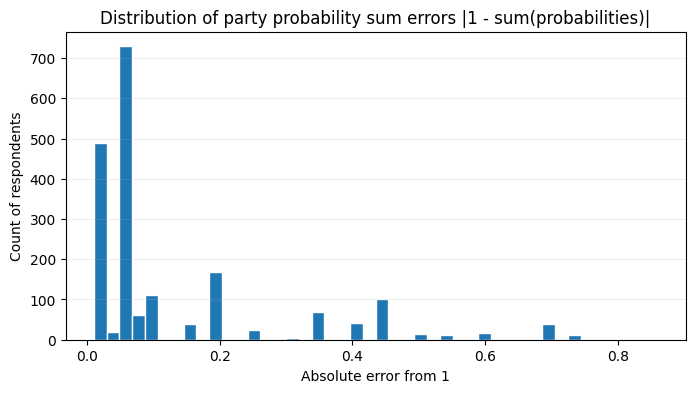

In [52]:
Visualization_Utils.visualize_party_errors([abs(1-s) for _, s, _ in bad_party_probs_sum])